# Intensity Transformations & Filtering Spatial Domain

## Thresholding

In [ ]:
import cv2
import matplotlib.pyplot as plt

# cv2_imshow is a Google Colab-only helper (google.colab.patches.cv2_imshow).
# Define a matplotlib-based fallback so this notebook also runs outside Colab (e.g. Jupyter/VS Code).
try:
    from google.colab.patches import cv2_imshow
except ImportError:
    def cv2_imshow(image):
        """Display an OpenCV (BGR or grayscale) image inline using matplotlib."""
        if image.ndim == 2:
            plt.imshow(image, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

In [ ]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

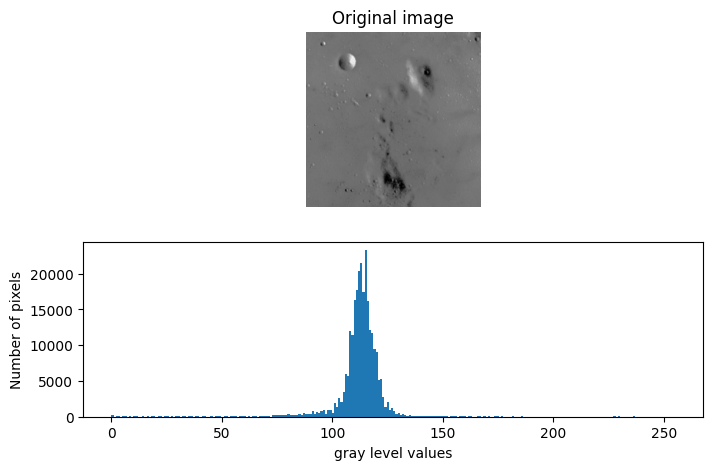

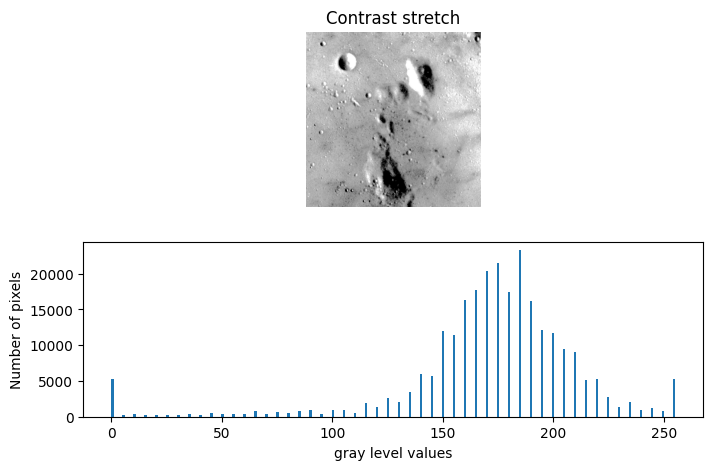

In [ ]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


### Task 1: Contrast stretching (3rd–80th percentile)

In [ ]:
# Task 1: Rescale intensity values to include the 3rd and 80th percentiles, and plot the histogram

# Compute the 3rd and 80th percentile intensity values of the moon image
p3, p80 = np.percentile(img, (3, 80))

# Apply contrast stretching using these percentiles as the input range
img_rescale_t1 = exposure.rescale_intensity(img, in_range=(p3, p80))

# Display the rescaled image alongside its histogram
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_t1, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd-80th percentile)')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_t1.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

### Task 2: Histogram equalization

In [ ]:
# Task 2: Flatten the histogram of the moon image using exposure.equalize_hist

# Apply histogram equalization (output is float in range [0, 1])
img_eq = exposure.equalize_hist(img)

# Display the equalized image alongside its histogram
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram equalized image')

fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

### Task 3: Histogram matching (rocket as reference, chelsea as source)

In [ ]:
# Task 3: Histogram matching using rocket (reference) and chelsea (source) images

# Load the source and reference images (both are color images)
reference = data.rocket()
source = data.chelsea()

# Match the histogram of the source image to that of the reference image, channel by channel
matched = exposure.match_histograms(source, reference, channel_axis=-1)

# Display the source, reference, and matched images side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(source)
axes[0].set_title('Source (chelsea)')
axes[0].axis('off')

axes[1].imshow(reference)
axes[1].set_title('Reference (rocket)')
axes[1].axis('off')

axes[2].imshow(matched)
axes[2].set_title('Matched (chelsea -> rocket)')
axes[2].axis('off')
plt.show()

# Plot the color histograms of source, reference, and matched images for comparison
fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharex=True, sharey=True)
images = (source, reference, matched)
titles = ('Source', 'Reference', 'Matched')
colors = ('red', 'green', 'blue')

for row, (image, title) in enumerate(zip(images, titles)):
    for col, color in enumerate(colors):
        img_hist, bins = exposure.histogram(image[..., col], source_range='dtype')
        axes[row, col].plot(bins, img_hist / img_hist.max(), color=color)
        if row == 0:
            axes[row, col].set_title(color)
    axes[row, 0].set_ylabel(title)

plt.tight_layout()
plt.show()